## Importación de librerías

In [1]:
import random
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Julio
[nltk_data]     GR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Precargado de datos

In [2]:
def identificar_clusters(text, labels, ye, encod):
    cluster_labels = {}
    for cluster in range(text['clf'].n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        if len(cluster_indices) == 0:
            cluster_labels[cluster] = "Sin datos"
        else:
            cluster_true_labels = ye[cluster_indices]
            most_common_label_num = Counter(cluster_true_labels).most_common(1)[0][0]
            most_common_label_str = encod.inverse_transform([[most_common_label_num]])[0][0]
            cluster_labels[cluster] = most_common_label_str

    return cluster_labels


dataset = 'news_reducido.csv'

# Leer los datos en formato csv
data = pd.read_csv(dataset)

# Nos quedamos con el texto (puedes quedarte con más información si quieres)
X = data['text'].astype(str).to_numpy()

# Ahora, procesamos las etiquetas, para cada clase, le asignamos un valor numérico entre 0 y el número de clases
enc = OrdinalEncoder()
y = enc.fit_transform(np.reshape(data['category'], (-1, 1))).reshape(-1)

# Hacemos la partición train-test con Validacion cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf.get_n_splits(X, y)

5

### Aplicacion de pipeline y entrenamiento para clustering

In [6]:
import time
# Pipeline optima para clustering #
text_tfidf = Pipeline([
    ('vect', CountVectorizer(max_df=0.8, min_df=2, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', KMeans(init='k-means++', max_iter=300, n_clusters=4, random_state=200)),
])

accuracies = np.zeros(5)
starttime = time.time()
text_tfidf.fit(X)
endtime = time.time()
labels = text_tfidf.predict(X)
acc = np.mean(labels == y)
print(f'TF-IDF: {acc}, tiempo de entrenamiento: {endtime-starttime:.2f} segundos')
etiquetas_usadas = identificar_clusters(text_tfidf, labels, y, enc)
print(etiquetas_usadas)

TF-IDF: 0.5282, tiempo de entrenamiento: 20.92 segundos
{0: 'TRAVEL', 1: 'POLITICS', 2: 'ENTERTAINMENT', 3: 'WELLNESS'}


## Preparación de datos para TSNE

In [11]:
transformed = text_tfidf.transform(X)
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(transformed)

C:\Users\Julio GR\AppData\Local\Temp\ipykernel_11040\2425526891.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('viridis', len(etiquetas_usadas))


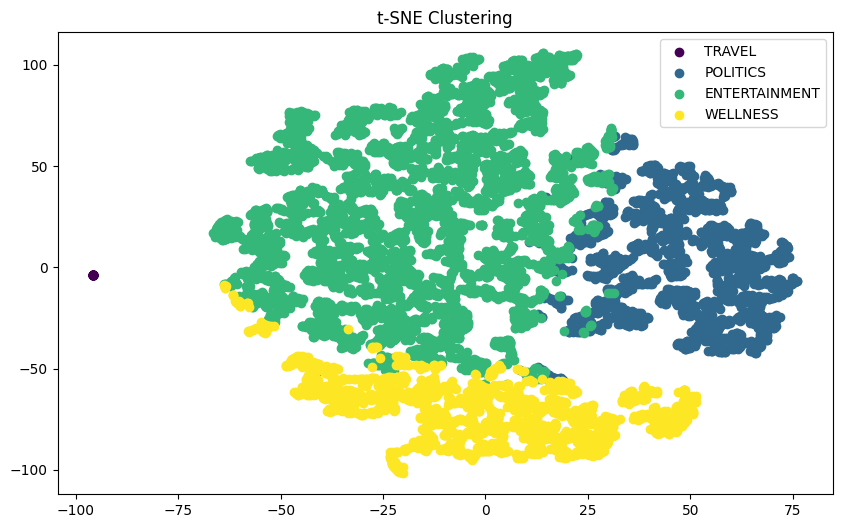

In [12]:
colores = plt.cm.get_cmap('viridis', len(etiquetas_usadas))
color_map = {etiqueta: colores(i) for i, etiqueta in enumerate(etiquetas_usadas.values())}

colores_asignados = [color_map[etiquetas_usadas[label]] for label in labels]
# Visualizacion de los clusteres
plt.figure(figsize=(10, 6))
for etiqueta, color in color_map.items():
    indices = [i for i, label in enumerate(labels) if etiquetas_usadas[label] == etiqueta]
    plt.scatter(X_embedded[indices, 0], X_embedded[indices, 1], label=etiqueta, color=color)

plt.title('t-SNE Clustering')
plt.legend()
plt.show()

## Evaluación de la calidad del clustering

In [33]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Silhouette Score
silhouette_avg = silhouette_score(text_tfidf.transform(X), labels)
print(f"Silhouette Score: {silhouette_avg:.2f}")

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(text_tfidf.transform(X), labels)
print(f"Davies-Bouldin Index: {davies_bouldin:.2f}")

Silhouette Score: 0.39
Davies-Bouldin Index: 0.72


## Mezcla de Gaussianas

Gaussian Mixture: 0.3418, tiempo de entrenamiento: 0.19 segundos


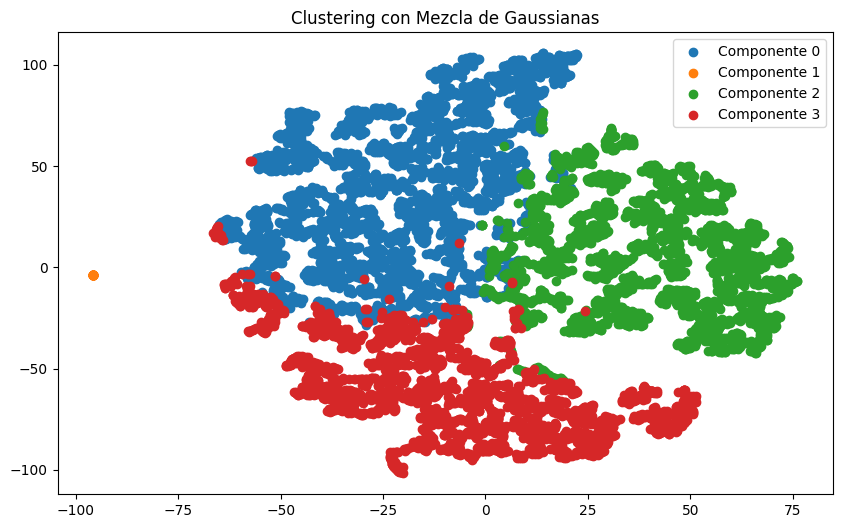

In [7]:
from sklearn.mixture import GaussianMixture

X_transform = text_tfidf.transform(X)

tsne = TSNE(n_components=2, random_state=42)
gmm = GaussianMixture(n_components=4, random_state=42)

X_embedded = tsne.fit_transform(X_transform)

starttime = time.time()
gmm.fit(X_transform)
endtime = time.time()
# Predecir las etiquetas de los datos
gmm_labels = gmm.predict(X_transform)

acc_gmm = np.mean(gmm_labels == y)
print(f'Gaussian Mixture: {acc_gmm}, tiempo de entrenamiento: {endtime-starttime:.2f} segundos')

# Visualización de los resultados
plt.figure(figsize=(10, 6))
for i in range(4):
    indices = [j for j, label in enumerate(gmm_labels) if label == i]
    plt.scatter(X_embedded[indices, 0], X_embedded[indices, 1], label=f'Componente {i}')

plt.title('Clustering con Mezcla de Gaussianas')
plt.legend()
plt.show()

## Clasificacion

Ejecuta el grid search para obtener la mejor configuracion para este clasificador.

In [ ]:
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 9],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan'],
    'clf__p': [1, 2],
    'clf__algorithm': ['auto']
}

grid_search_tfidf = GridSearchCV(
    text_tfidf,
    param_grid_knn,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Adjust scoring if needed
    n_jobs=-1,
    verbose=1
)
grid_search_tfidf.fit(X, y)

print("mejores parametros: ", grid_search_tfidf.best_params_)
print("mejor score: ", grid_search_tfidf.best_score_)

Knn para binario y frecuencia

In [43]:
text_nb_binary = Pipeline([
    ('count', CountVectorizer(binary=True,max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', MultinomialNB()),
])
text_nb_frecuency = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('clf', MultinomialNB()),
])

# Entrenamiento del clasificador
text_nb_binary.fit(X, y)
text_nb_frecuency.fit(X, y)
predictedNbBinary = text_nb_binary.predict(X)
predictedNbFrecuency = text_nb_frecuency.predict(X)
acc_nb_binary = np.mean(predictedNbBinary == y)
acc_nb_frecuency = np.mean(predictedNbFrecuency == y)

print(f'MultinomialNBClassifier binary: {acc_nb_binary}')
print(f'MultinomialNBClassifier frecuency: {acc_nb_frecuency}')

MultinomialNBClassifier binary: 0.9521
MultinomialNBClassifier frecuency: 0.9658


In [45]:
text_knn_binary = Pipeline([
    ('count', CountVectorizer(binary=True,max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', KNeighborsClassifier()),
])
text_knn_frecuency = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('clf', KNeighborsClassifier()),
])

param_grid_knn = {
    'clf__weights': ['uniform', 'distance'],
    'clf__p': [1, 2],
}

grid_search_knn_binary = GridSearchCV(
    text_knn_binary,
    param_grid_knn,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Adjust scoring if needed
    n_jobs=-1,
    verbose=1
)
grid_search_knn_frecuency = GridSearchCV(
    text_knn_frecuency,
    param_grid_knn,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Adjust scoring if needed
    n_jobs=-1,
    verbose=1
)


grid_search_knn_binary.fit(X, y)
grid_search_knn_frecuency.fit(X, y)

print()

print("mejores parametros knn binary: ", grid_search_knn_binary.best_params_)
print("mejor score knn binary: ", grid_search_knn_binary.best_score_)
print("mejores parametros knn frecuency: ", grid_search_knn_frecuency.best_params_)
print("mejor score knn frecuency: ", grid_search_knn_frecuency.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits

mejores parametros knn binary:  {'clf__p': 2, 'clf__weights': 'distance'}
mejor score knn binary:  0.9029
mejores parametros knn frecuency:  {'clf__p': 2, 'clf__weights': 'distance'}
mejor score knn frecuency:  0.5359


In [3]:
import time
text_knn = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', KNeighborsClassifier(weights='distance', p=2)),
])

# Entrenamiento del clasificador
starttime = time.time()
text_knn.fit(X, y)
endtime = time.time()
predictedKnn = text_knn.predict(X)
acc_knn = np.mean(predictedKnn == y)
print(f'KNeighborslassifier: {acc_knn}, tiempo de entrenamiento: {endtime-starttime:.2f} segundos')

KNeighborslassifier: 0.9981, tiempo de entrenamiento: 14.82 segundos


In [5]:
import time
text_knn_binary = Pipeline([
    ('count', CountVectorizer(binary=True,max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', KNeighborsClassifier(weights='distance', p=2)),
])

starttime = time.time()
text_knn_binary.fit(X, y)
endtime = time.time()
predictedKnnBinary = text_knn_binary.predict(X)
acc_knn_binary = np.mean(predictedKnnBinary == y)
print(f'KNeighborslassifier binary: {acc_knn_binary}, tiempo de entrenamiento: {endtime - starttime:.2f} segundos')

KNeighborslassifier binary: 0.9981, tiempo de entrenamiento: 23.72 segundos


In [6]:
import time
text_knn_frecuency = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('clf', KNeighborsClassifier(weights='distance', p=2)),
])

starttime = time.time()
text_knn_frecuency.fit(X, y)
endtime = time.time()
predictedKnnFrecuency = text_knn_frecuency.predict(X)
acc_knn_frecuency = np.mean(predictedKnnFrecuency == y)
print(f'KNeighborslassifier frecuency: {acc_knn_frecuency}, tiempo de entrenamiento: {endtime - starttime:.2f} segundos')

KNeighborslassifier frecuency: 0.9981, tiempo de entrenamiento: 12.08 segundos


In [8]:
labels = text_knn.named_steps['clf'].classes_
print(enc.inverse_transform(labels.reshape(-1, 1)))

[['ENTERTAINMENT']
 ['POLITICS']
 ['TRAVEL']
 ['WELLNESS']]


In [15]:
frase = ["i'm gonna vote Donald Trump"]
predict = text_knn.predict(frase)
categoria = enc.inverse_transform(predict.reshape(-1, 1))
print(f'La categoria es: {categoria[0][0]}')

La categoria es: POLITICS


## Clasificacion con Naive-Bayes

In [8]:
text_NB = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', MultinomialNB()),
])

# Entrenamiento del clasificador


text_NB.fit(X, y)
predictedNB = text_NB.predict(X)
acc_nb = np.mean(predictedNB == y)
print(f'MultinomialNB: {acc_nb}')

#Para resumir, GaussianNB no tiene sentido usarla existiendo MultinomialNB, en casi todos los foros aseguran que es mucho mejor la Multinomial y que existiendo ésta, no tiene algún sentido usar GaussianNB...
'''
text_gaussian = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', GaussianNB()),
])

X_denso = np.array(data['text'].astype(str))
text_gaussian.fit(X_denso, y)
predictedGaussian = text_gaussian.predict(X_denso)
acc_gaussian = np.mean(predictedGaussian == y)
print(f'GaussianNB: {acc_gaussian}')
'''
print()
labels = text_NB.named_steps['clf'].classes_
print(enc.inverse_transform(labels.reshape(-1, 1)))

MultinomialNB: 0.9544

[['ENTERTAINMENT']
 ['POLITICS']
 ['TRAVEL']
 ['WELLNESS']]


In [9]:
text_NB = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', MultinomialNB()),
])

param_grid_nb = {
    'clf__alpha': [0.1, 0.5, 1.0, 1.5, 2.0],
    'clf__fit_prior': [True, False]
}
grid_search_nb = GridSearchCV(
    text_NB,
    param_grid_nb,
    cv=3,  # 5-fold cross-validation
    scoring='accuracy',  # Adjust scoring if needed
    n_jobs=-1,
    verbose=1
)
grid_search_nb.fit(X, y)

print("mejores parametros: ", grid_search_nb.best_params_)
print("mejor score: ", grid_search_nb.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
mejores parametros:  {'clf__alpha': 0.1, 'clf__fit_prior': True}
mejor score:  0.9293032482612388


In [7]:
import time
text_NB = Pipeline([
    ('count', CountVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))),
    ('tfidf', TfidfTransformer(norm='l2')),
    ('clf', MultinomialNB(alpha=0.1,fit_prior=True)),
])

# Entrenamiento del clasificador

starttime = time.time()
text_NB.fit(X, y)
endtime = time.time()
predictedNB = text_NB.predict(X)
acc_nb = np.mean(predictedNB == y)
print(f'MultinomialNB: {acc_nb}, tiempo de entrenamiento: {endtime-starttime:.2f}')

MultinomialNB: 0.9758, tiempo de entrenamiento: 10.65


Modelo sin optimizar y despues modelo optimizado mediante GridSearching.
Observaciones: Knn da mas precisión a cambio de mayor tiempo

In [4]:
import time
import numpy as np
import gc

class DenseTransformer(TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X.toarray()

text_Gaus = Pipeline([
    ('count', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('dense', DenseTransformer()),
    ('clf', GaussianNB()),
])

def generar_lotes(X, y, tamano_lote):
    for i in range(0, len(X), tamano_lote):
        yield X[i:i + tamano_lote], y[i:i + tamano_lote]

tamano_lote = 5000
nLote = 0

starttime = time.time()
for X_lote, y_lote in generar_lotes(X, y, tamano_lote):
    try:
        # Entrenar o predecir con el modelo usando el lote
        text_Gaus.fit(X_lote, y_lote)
        predicciones = text_Gaus.predict(X_lote)
        acc_gauss = np.mean(predicciones == y_lote)
        print(f"Precisión para el lote{nLote}: {acc_gauss:.2f}")
    except MemoryError:
        print("Error de memoria procesando el lote. Intenta reducir el tamaño del lote.")
    finally:
        nLote += 1
        # Liberar memoria después de procesar cada lote
        del X_lote, y_lote, predicciones
        gc.collect()

endtime = time.time()
print(f'Tiempo total de entrenamiento: {endtime - starttime:.2f} segundos')

Precisión para el lote0: 1.00
Precisión para el lote1: 0.99
